In [ ]:
import pandas as pd
import numpy as np
#dataset
data={
'Weather':['Sunny', 'Sunny', 'Cloudy', 'Rainy', 'Rainy', 'Rainy', 'Cloudy', 'Sunny', 'Sunny', 'Rainy', 'Sunny', 'Cloudy', 'Cloudy', 'Rainy'],
'Temperature':['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
'Soil Moisture':['Dry', 'Dry', 'Dry', 'Dry', 'Moist', 'Moist', 'Moist', 'Dry', 'Moist', 'Moist', 'Moist', 'Dry', 'Moist', 'Dry'],
'Wind':['Weak','Strong','Weak','Weak','Weak','Strong', 'Strong', 'Weak','Weak','Weak','Strong','Strong', 'Weak', 'Strong'],
'Irrigate': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df=pd.DataFrame(data)
print(df)

#step 1:entropy
def entropy(target):
  values, counts=np.unique(target,return_counts=True)
  prob=counts/counts.sum()
  return-np.sum(prob*np.log2(prob))

#step 2:information gain
def information_gain(data,feature,target_name):
  total_entropy=entropy(data[target_name])

  values,counts=np.unique(data[feature],return_counts=True)
  weighted_entropy=0
  for i in range(len(values)):
    subset=data[data[feature]==values[i]]
    weighted_entropy+=(counts[i]/np.sum(counts))*entropy(subset[target_name])
    return total_entropy - weighted_entropy

#step 3: ID3 Algorithm
def id3(data,features,target_name,depth=0):
  indent=""*depth

  #if all target values are same-> return leaf
  if len(np.unique(data[target_name]))==1:
    return np.unique(data[target_name])[0]

#if no features left-> return majority class
  if len(features)==0:
    return data[target_name].mode()[0]

#compute IG for all features
  gains=[]
  print(f"\n{indent}Evaluating features at depth{depth}:")

  for feature in features:
   gain=information_gain(data,feature,target_name)
   gains.append(gain)
   print(f"{indent}IG({feature})={gain:.4f}")

#select best feature
  best_feature=features[np.argmax(gains)]
  print(f"{indent}Best Feature->{best_feature}")

  tree={best_feature:{}}

#split dataset
  for value in np.unique(data[best_feature]):
    print(f"{indent}Splitting {best_feature}={value}")

    subset=data[data[best_feature]==value]

    if subset.shape[0]==0:
     tree[best_feature][value]=data[target_name].mode([0])
    else:
     remaining_features=[f for f in features if f!=best_feature]

     subtree=id3(subset,remaining_features,target_name,depth+1)
     tree[best_feature][value]=subtree

  return tree


#step 4 : print tree function
def print_tree(tree,indent=""):
  if not isinstance(tree,dict):
    print(indent+"->",tree)
    return

  for feature, branches in tree.items():
    for value,subtree in branches.items():
      print(f"{indent}{feature}={value}:")
      print_tree(subtree,indent+" ")


#step 5: build tree
features=list(df.columns[:-1])

tree_model=id3(df,features,'Irrigate')


#step 6:Display tree
print("\n Final Decision Tree:\n")
print_tree(tree_model)





   Weather Temperature Soil Moisture    Wind Irrigate
0    Sunny         Hot           Dry    Weak       No
1    Sunny         Hot           Dry  Strong       No
2   Cloudy         Hot           Dry    Weak      Yes
3    Rainy        Mild           Dry    Weak      Yes
4    Rainy        Cool         Moist    Weak      Yes
5    Rainy        Cool         Moist  Strong       No
6   Cloudy        Cool         Moist  Strong      Yes
7    Sunny        Mild           Dry    Weak       No
8    Sunny        Cool         Moist    Weak      Yes
9    Rainy        Mild         Moist    Weak      Yes
10   Sunny        Mild         Moist  Strong      Yes
11  Cloudy        Mild           Dry  Strong      Yes
12  Cloudy         Hot         Moist    Weak      Yes
13   Rainy        Mild           Dry  Strong       No

Evaluating features at depth0:
IG(Weather)=0.9403
IG(Temperature)=0.7085
IG(Soil Moisture)=0.4477
IG(Wind)=0.5117
Best Feature->Weather
Splitting Weather=Cloudy
Splitting Weather=Rainy

Eva

   Weather   Soil Temperature Humidity    Wind Fertilizer Crop Type  Season
0    rainy  moist         hot     high    weak        yes      corn    rabi
1    sunny    dry        cool      low    weak        yes      rice    rabi
2    rainy  moist        mild   medium  strong        yes      rice  kharif
3    rainy  moist        cool     high  strong        yes      rice  kharif
4    sunny  moist        cool     high    weak         no      rice  kharif
5    sunny  moist         hot     high  strong         no      rice  summer
6    rainy  moist        cool      low    weak        yes     wheat    rabi
7   cloudy  moist         hot      low    weak         no      corn  summer
8    rainy  moist        cool   medium  strong         no      rice  kharif
9    rainy    dry        mild      low  strong         no      corn    rabi
10   rainy    wet        cool     high    weak         no      corn  summer
11   rainy  moist         hot   medium    weak        yes      rice    rabi
12   sunny  

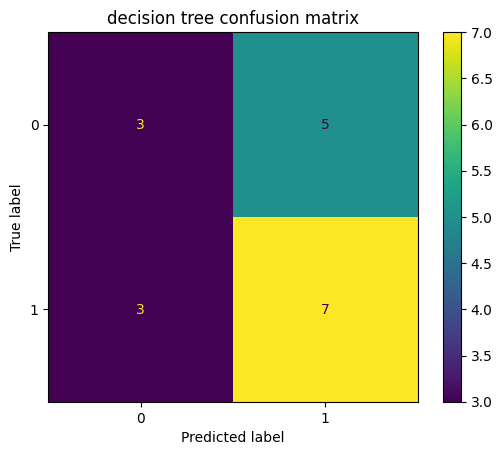

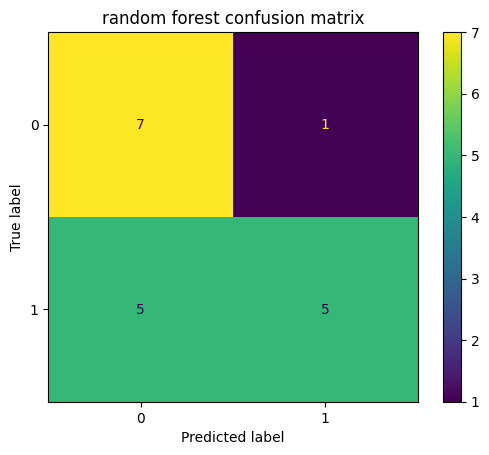


cross validation accuracy:

decision tree: 0.5666666666666667

random forest: 0.6833333333333333

 feature importance:
        feature  importance
3     Humidity    0.220475
1         Soil    0.175184
0      Weather    0.127271
6    Crop Type    0.127009
7       Season    0.122067
2  Temperature    0.102054
4         Wind    0.080892
5   Fertilizer    0.045049


In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

#2. generate larger farming dataset(8 features)
np.random.seed(42)

n_samples=60

data={
  'Weather':np.random.choice(['sunny','cloudy','rainy'],n_samples),
  'Soil':np.random.choice(['dry','moist','wet'],n_samples),
  'Temperature':np.random.choice(['hot','mild','cool'],n_samples),
  'Humidity':np.random.choice(['high','medium','low'],n_samples),
  'Wind':np.random.choice(['strong','weak'],n_samples),
  'Fertilizer':np.random.choice(['yes','no'],n_samples),
  'Crop Type':np.random.choice(['wheat','rice','corn'],n_samples),
  'Season':np.random.choice(['kharif','rabi','summer'],n_samples)
}

df=pd.DataFrame(data)
print(df)

#create target variable(rule-based for realism)
def irrigation_rule(row):
  if row['Soil']=='Dry' and row['Weather']!='Rainy':
    return 'Yes'
  elif row['Soil']=='Wet':
    return 'No'
  elif row['Humidity']=='High' and row['Weather']=='Rainy':
    return 'No'
  else:
    return np.random.choice(['Yes','No'])
df['Irrigate']=df.apply(irrigation_rule,axis=1)
print('Sample Dataset:\n',df.head())

#4. encode categorical variables
le_dict={}

for column in df.columns:
  le=LabelEncoder()
  df[column]=le.fit_transform(df[column])
  le_dict[column]=le


#5. split features and target
X=df.drop('Irrigate',axis=1)
y=df['Irrigate']

#6. train-test split(STRATIFIED)
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.3,random_state=42,stratify=y
)

#7.Decision tree model
dt_model=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

#8.random forest model
rf_model=RandomForestClassifier(
    n_estimators=20,
    criterion='entropy',
    random_state=42
)

rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)

#9.accuracy evaluation
dt_accuracy = accuracy_score(y_test,y_pred_dt)
rf_accuracy = accuracy_score(y_test,y_pred_rf)

print('\nAccuracy Comparison:')
print('decision tree accuracy:',dt_accuracy)
print('random forest accuracy:',rf_accuracy)

#10.confusion matrix (fixed+meaningful)
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

cm_dt_df=pd.DataFrame(cm_dt,index=['actual no','actual yes'],columns=['pred no','pred yes'])
cm_rf_df=pd.DataFrame(cm_rf,index=['actual no','actual yes'],columns=['pred no','pred yes'])

#11. confusion matrix visualization
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt,labels=[0,1])
plt.title('decision tree confusion matrix')
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf,labels=[0,1])
plt.title('random forest confusion matrix')
plt.show()

#12. cross validation
dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print('\ncross validation accuracy:')
print('\ndecision tree:',dt_cv.mean())
print('\nrandom forest:',rf_cv.mean())

#13.feature importance (random forest)

importance=pd.DataFrame({
    'feature':X.columns,
    'importance':rf_model.feature_importances_
}).sort_values(by='importance',ascending=False)

print('\n feature importance:\n',importance)










Accuracy Comparison:
decision tree accuracy: 0.5777777777777777
random forest accuracy: 0.5222222222222223

decision tree confusion matrix:
 [[17 22]
 [16 35]]

random forest confusion matrix:
 [[12 27]
 [16 35]]


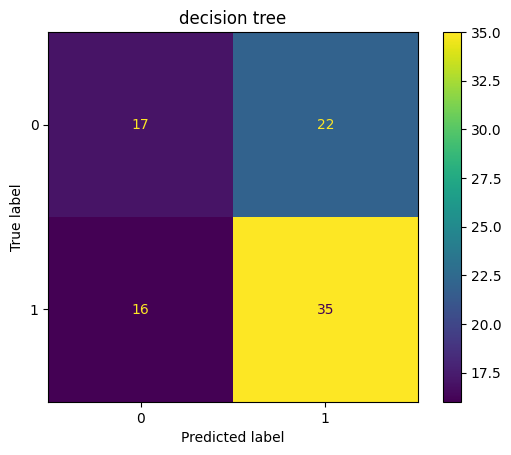

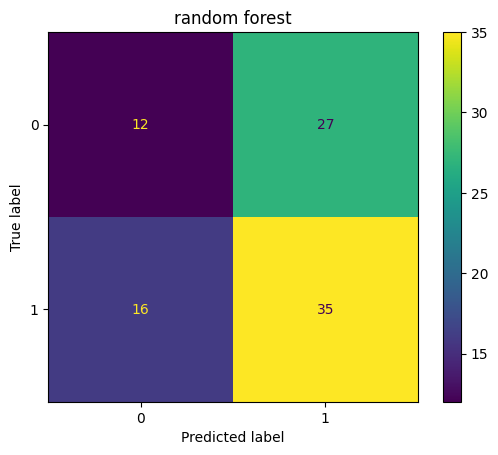


cross validation accuracy:

decision tree: 0.5433333333333333

random forest: 0.54


In [11]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

#2.generate larger dataset
np.random.seed(42)
random.seed(42)

n_samples=300

data={
'Weather': np.random.choice(['Sunny', 'Cloudy', 'Rainy'],n_samples),
'Soil': np.random.choice(['Dry','Moist', 'Wet'], n_samples),
'Temperature': np.random.choice(['Hot', 'Mild', 'Cool'],n_samples),
'Humidity': np.random.choice(['High', 'Medium', 'Low'],n_samples),
'Wind': np.random.choice(['Strong', 'Weak'], n_samples),
'Fertilizer': np.random.choice(['Yes','No'], n_samples),
'CropType': np. random.choice( ['Wheat','Rice','Corn'],n_samples),
'Season': np. random.choice(['Kharif','Rabi','Summer'],n_samples)
}
df=pd.DataFrame(data)

#3.target with noise

def irrigation_rule(row):
  if row['Soil']=='Dry' and row['Weather']!='Rainy':
    base='Yes'
  elif row['Soil']=='wet':
    base='No'
  else:
    base=random.choice(['Yes','No'])

  if random.random()<0.2:
    return 'No' if base=='Yes' else 'Yes'
  return base

df['Irrigate']=df.apply(irrigation_rule,axis=1)

#4.encode data
le=LabelEncoder()
for col in df.columns:
    df[col]=le.fit_transform(df[col])

#5.split data
X=df.drop('Irrigate',axis=1)
y=df['Irrigate']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)


#6. decision tree(high variance)
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

#7.random forest(variance reduction)
rf_model=RandomForestClassifier(n_estimators=100,max_features='sqrt',random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

#8.accuracy comparision
dt_acc=accuracy_score(y_test,y_pred_dt)
rf_acc=accuracy_score(y_test,y_pred_rf)

print('\nAccuracy Comparison:')
print('decision tree accuracy:',dt_acc)
print('random forest accuracy:',rf_acc)

#9.confusion matrix
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

print('\ndecision tree confusion matrix:\n',cm_dt)
print('\nrandom forest confusion matrix:\n',cm_rf)

#10.visual confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title('decision tree')
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)
plt.title('random forest')
plt.show()

#11. cross validation
dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print('\ncross validation accuracy:')
print('\ndecision tree:',dt_cv.mean())
print('\nrandom forest:',rf_cv.mean())